In [1]:
import numpy as np

from mgwr.gwr import GWR as OfficialGWR
from mgwr.sel_bw import Sel_BW

from src.log.gwr_logger import GwrLogger
from src.kernel.gwr_kernel import GwrKernel
from src.model.gwr import GWR
from src.dataset.simulated_spatial_dataset import SimulatedSpatialDataset
from src.model.lgwr import LGWR
from src.kernel.lgwr_kernel import LgwrKernel

k = 1
field_size = 40

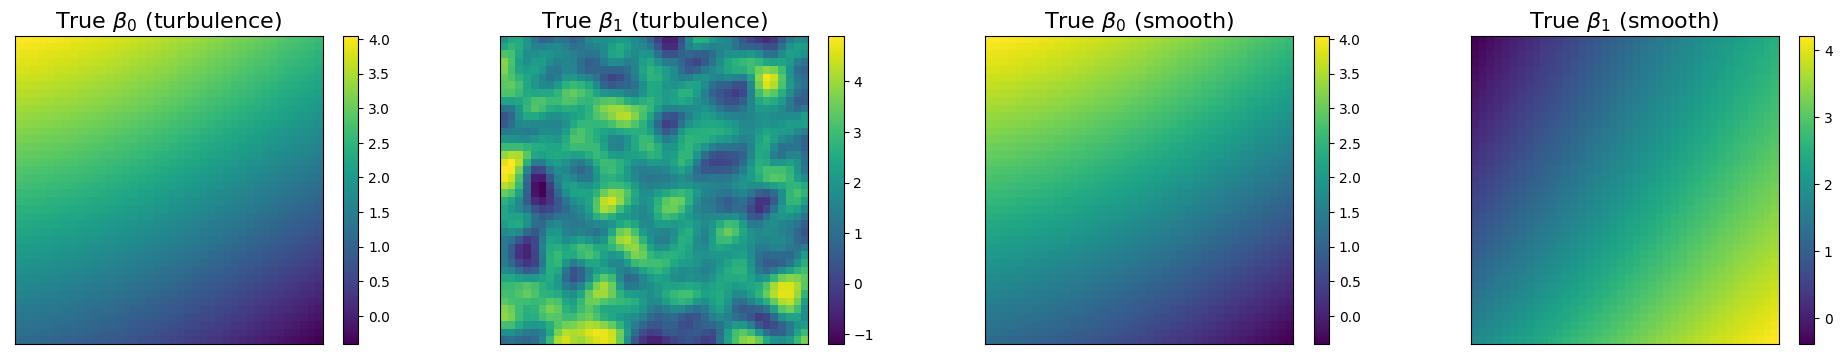

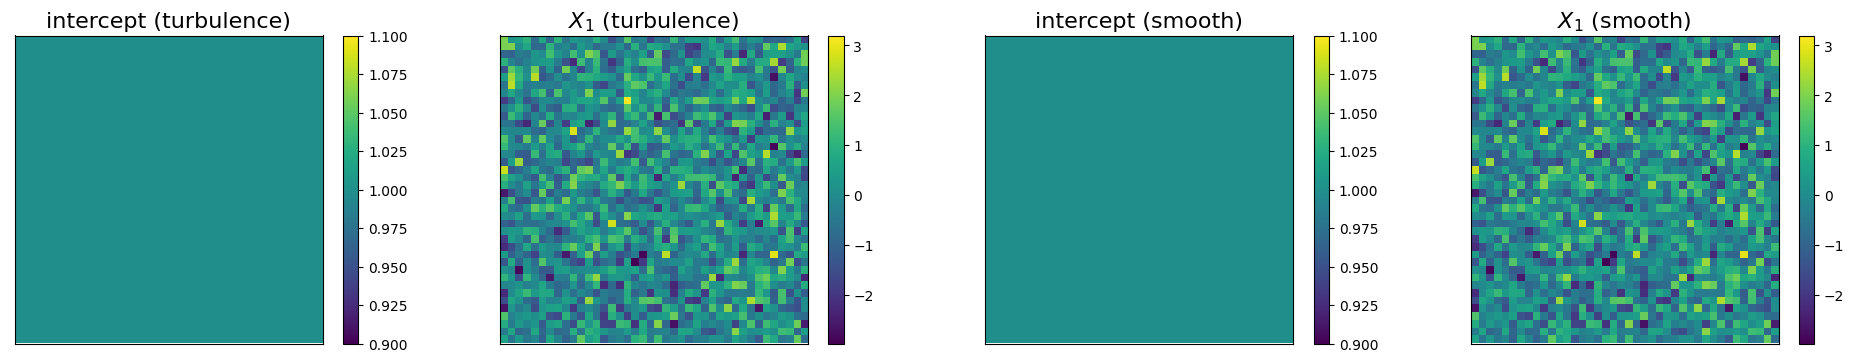

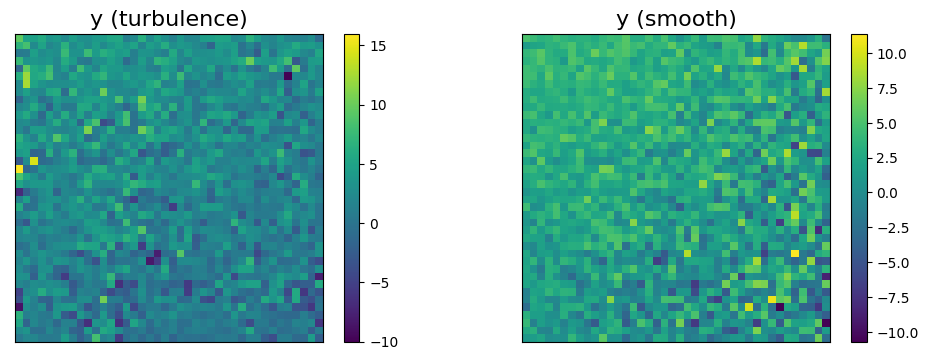

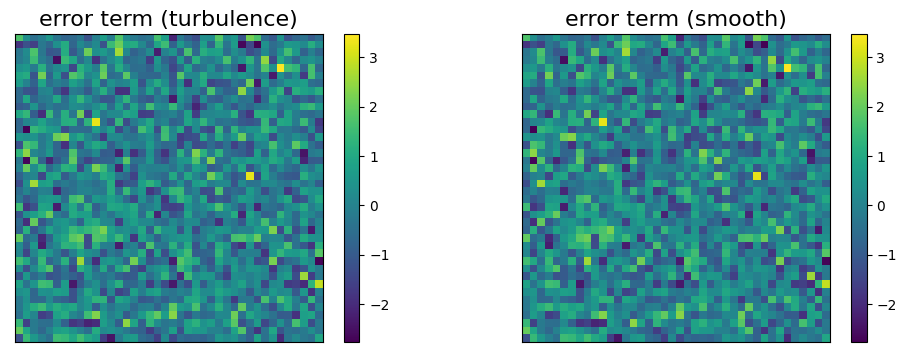

In [2]:

dataset_turbulence = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 2]
)
[X_turbulence] = dataset_turbulence.generate_data()
[beta_turbulence] = dataset_turbulence.generate_processes()
[y_turbulence, err_turbulence] = dataset_turbulence.fit_y(
    X_turbulence, beta_turbulence
)

dataset_smooth = SimulatedSpatialDataset(
    k=k,
    field_size=field_size,
    process_seed=[666, 888],
    len_scale_seed=[100, 100]
)
[X_smooth] = dataset_smooth.generate_data()
[beta_smooth] = dataset_smooth.generate_processes()
[y_smooth, err_smooth] = dataset_smooth.fit_y(
    X_smooth, beta_smooth
)


dataset_turbulence.plot(
    b=np.vstack([beta_turbulence.T, beta_smooth.T]),
    sub_title=[
        r"True $\beta_0$ (turbulence)", 
        r"True $\beta_1$ (turbulence)", 
        r"True $\beta_0$ (smooth)",
        r"True $\beta_1$ (smooth)"
    ],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([X_turbulence.T, X_smooth.T]),
    sub_title=[
        r"intercept (turbulence)", 
        r"$X_1$ (turbulence)", 
        r"intercept (smooth)", 
        r"$X_1$ (smooth)"
    ],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([y_turbulence.reshape(1, -1), y_smooth.reshape(1, -1)]),
    sub_title=['y (turbulence)', 'y (smooth)'],
    size=field_size
)

dataset_turbulence.plot(
    b=np.vstack([err_turbulence.reshape(1, -1), err_smooth.reshape(1, -1)]),
    sub_title=['error term (turbulence)', 'error term (smooth)'],
    size=field_size
)

use golden search to find a global optimal bandwidth

In [3]:
g_X_turbulence = dataset_turbulence.X[:, 1:]
g_y_turbulence = dataset_turbulence.y.reshape(-1, 1)
g_coords_turbulence = dataset_turbulence.coordinates.tolist()

gwr_selector_turbulence = Sel_BW(
    g_coords_turbulence, 
    g_y_turbulence, 
    g_X_turbulence
)
gwr_bw_turbulence = gwr_selector_turbulence.search(bw_min=2)
official_gwr_turbulence = OfficialGWR(
    g_coords_turbulence, 
    g_y_turbulence, 
    g_X_turbulence, 
    gwr_bw_turbulence
).fit()


g_X_smooth = dataset_smooth.X[:, 1:]
g_y_smooth = dataset_smooth.y.reshape(-1, 1)
g_coords_smooth = dataset_smooth.coordinates.tolist()
gwr_selector_smooth = Sel_BW(
    g_coords_smooth, 
    g_y_smooth, 
    g_X_smooth
)
gwr_bw_smooth = gwr_selector_smooth.search(bw_min=2)
official_gwr_smooth = OfficialGWR(
    g_coords_smooth, 
    g_y_smooth, 
    g_X_smooth, 
    gwr_bw_smooth
).fit()







# n = X.shape[0]
# local_bandwidth_vector = np.full(n, 70, dtype=int)
# # bump ~5% of locations to 71 (random but reproducible)
# rng = np.random.default_rng(42)
# num_up = max(1, int(n * 0.05))
# local_bandwidth_vector[rng.choice(n, size=num_up, replace=False)] = 71

# kernel = LgwrKernel(dataset, 'bisquare')
# lgwr = LGWR(dataset, kernel)
# print(lgwr.update_local_bandwidth_vector(local_bandwidth_vector).fit().aicc)

In [4]:
# formatted comparison between the two official GWR fits
print("="*60)
print("GWR Model Comparison")
print("="*60)
print(f"{'Metric':30} {'Turbulence':>12} {'Smooth':>15}")
print("-"*60)
print(f"{'Global bandwidth':30} {int(gwr_bw_turbulence):12d} {int(gwr_bw_smooth):15d}")
print(f"{'R-squared':30} {official_gwr_turbulence.R2:12.4f} {official_gwr_smooth.R2:15.4f}")
print(f"{'AIC':30} {official_gwr_turbulence.aic:12.2f} {official_gwr_smooth.aic:15.2f}")
print(f"{'AICc':30} {official_gwr_turbulence.aicc:12.2f} {official_gwr_smooth.aicc:15.2f}")
print("-"*60)
print("="*60)

GWR Model Comparison
Metric                           Turbulence          Smooth
------------------------------------------------------------
Global bandwidth                         44             186
R-squared                            0.8687          0.8687
AIC                                 4875.78         4514.41
AICc                                4942.36         4517.47
------------------------------------------------------------


In [9]:
lgwr_kernel_smooth = LgwrKernel(dataset_smooth, 'bisquare')
lgwr_smooth = LGWR(dataset_smooth, lgwr_kernel_smooth)

lgwr_kernel_turbulence = LgwrKernel(dataset_turbulence, 'bisquare')
lgwr_turbulence = LGWR(dataset_turbulence, lgwr_kernel_turbulence)


local_bandwidth_vector = np.full(dataset_turbulence.n, 44, dtype=int)
# bump ~5% of locations to 71 (random but reproducible)
rng = np.random.default_rng(42)
num_up = max(1, int(dataset_turbulence.n * 0.3))
local_bandwidth_vector[rng.choice(dataset_turbulence.n, size=num_up, replace=False)] = 45


print(
    lgwr_turbulence
    .update_local_bandwidth_vector(local_bandwidth_vector)
    .fit()
    .aicc
)
print(
    lgwr_smooth
    .update_local_bandwidth_vector(local_bandwidth_vector)
    .fit()
    .aicc
)

4943.139220458565
4651.925325603307
